In [4]:
import numpy as np

In [7]:
#Exercício 1.1

n=25

numero_resposta = 5

xi = 1

for i in range(1,11):
    xi = (xi + n/xi)/2
    print((np.abs(numero_resposta - xi) / np.abs(numero_resposta))*100)

160.0
49.23076923076923
8.12053925455988
0.30495203889795874
0.00046356507898082095
1.0744471978796355e-09
0.0
0.0
0.0
0.0


In [ ]:
#Exercício 1.2

def calcular_epsilon_manual():
    e = 1.0
    
    while (1.0 + e) > 1.0:
        e = e / 2.0

    return e * 2.0

eps_manual = calcular_epsilon_manual()

# Cálculo via Numpy (Equivalente ao padrão da máquina)
eps_numpy = np.finfo(float).eps

print(f"Epsilon calculado manualmente: {eps_manual}")
print(f"Epsilon obtido via Numpy:      {eps_numpy}")

# Comparação
if eps_manual == eps_numpy:
    print("\nOs resultados são idênticos!")
else:
    print(f"\nDiferença detectada: {abs(eps_manual - eps_numpy)}")

Epsilon calculado manualmente: 2.220446049250313e-16
Epsilon obtido via Numpy:      2.220446049250313e-16

Os resultados são idênticos!


In [ ]:
# Exercício 1.3

x = 1/3

for i in range(50):
    x = (x * 4) - 1
    print(x)

#O resultado converge para aproximar o resultado mais proximo em casas decimais de 1/3

0.33333333333333326
0.33333333333333304
0.33333333333333215
0.3333333333333286
0.3333333333333144
0.33333333333325754
0.33333333333303017
0.3333333333321207
0.3333333333284827
0.3333333333139308
0.3333333332557231
0.3333333330228925
0.3333333320915699
0.3333333283662796
0.3333333134651184
0.33333325386047363
0.33333301544189453
0.3333320617675781
0.3333282470703125
0.33331298828125
0.333251953125
0.3330078125
0.33203125
0.328125
0.3125
0.25
0.0
-1.0
-5.0
-21.0
-85.0
-341.0
-1365.0
-5461.0
-21845.0
-87381.0
-349525.0
-1398101.0
-5592405.0
-22369621.0
-89478485.0
-357913941.0
-1431655765.0
-5726623061.0
-22906492245.0
-91625968981.0
-366503875925.0
-1466015503701.0
-5864062014805.0
-23456248059221.0


In [ ]:
# Exercício 1.4

u = 0.001

x = (1/u)/1+(1/u)

print(x)

y = 1/((-1/u) + 1)

print(y)

#A primeira função é mais ideial para números pequenos

2000.0
-0.001001001001001001


In [ ]:
#Exercício 1.5

x = 1 * 10 ** -15
y = (1 + x) - 1 / x

print(y)

#Apresenta um aumento gradativo ao diminuir o tamanho do x

-999999999999998.9


In [26]:
#Exercício 1.6

def serieTaylor(k):
    l = np.array([])
    for n in range(k):
        l = np.append(l,[(4*((-1)**n)) * (1/(2*n + 1))])
    return(l.sum())

def formulaMachin():

    return 4*(4 * np.arctan(1/5) - np.arctan(1/239))

def formulaHutton():

    return 4*(np.arctan(1/2) + np.arctan(1/3))

def formulaClausen():

    return 4*(2 * np.arctan(1/3) + np.arctan(1/7))

def formulaDase():

    return  4*(np.arctan(1/2) + np.arctan(1/5) + np.arctan(1/8))

In [28]:
print(serieTaylor(20))

print(formulaMachin())

print(formulaHutton())

print(formulaClausen())

print(formulaDase())

3.091623806667839
3.1415926535897936
3.141592653589793
3.141592653589793
3.141592653589793


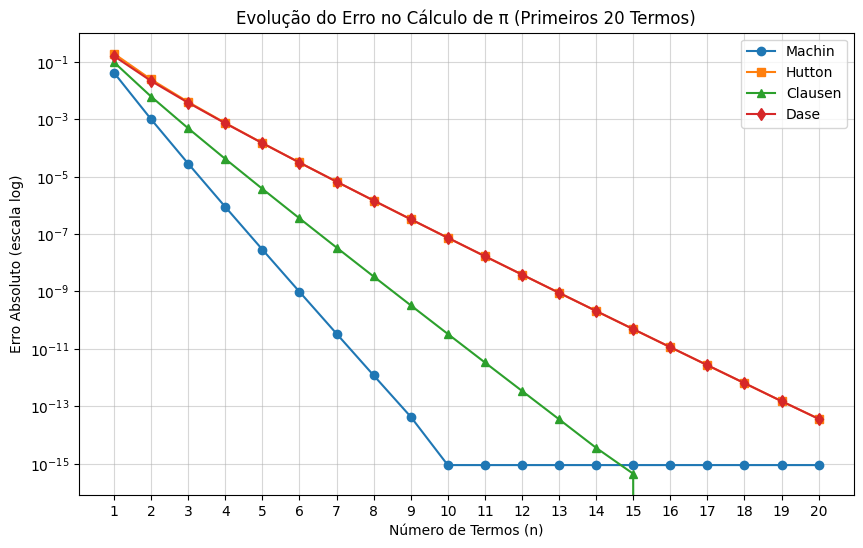

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Função para calcular a série de Taylor do arctan até N termos
def arctan_taylor(x, n_terms):
    n = np.arange(n_terms)
    # Fórmula da série de Taylor fornecida
    termos = ((-1)**n * (x**(2*n + 1))) / (2*n + 1)
    return np.cumsum(termos) # Retorna a evolução da soma termo a termo

# Configurações
termos_considerados = 20
n_eixo = np.arange(1, termos_considerados + 1)
pi_real = np.pi

# 2. Cálculo para cada método
# Fórmula de Machin: pi/4 = 4*atan(1/5) - atan(1/239)
pi_machin = 4 * (4 * arctan_taylor(1/5, termos_considerados) - arctan_taylor(1/239, termos_considerados))

# Fórmula de Hutton: pi/4 = atan(1/2) + atan(1/3)
pi_hutton = 4 * (arctan_taylor(1/2, termos_considerados) + arctan_taylor(1/3, termos_considerados))

# Fórmula de Clausen: pi/4 = 2*atan(1/3) + atan(1/7)
pi_clausen = 4 * (2 * arctan_taylor(1/3, termos_considerados) + arctan_taylor(1/7, termos_considerados))

# Fórmula de Dase: pi/4 = atan(1/2) + atan(1/5) + atan(1/8)
pi_dase = 4 * (arctan_taylor(1/2, termos_considerados) + arctan_taylor(1/5, termos_considerados) + arctan_taylor(1/8, termos_considerados))

# 3. Cálculo do erro absoluto
erro_machin = np.abs(pi_real - pi_machin)
erro_hutton = np.abs(pi_real - pi_hutton)
erro_clausen = np.abs(pi_real - pi_clausen)
erro_dase = np.abs(pi_real - pi_dase)

# 4. Geração do Gráfico
plt.figure(figsize=(10, 6))
plt.plot(n_eixo, erro_machin, label='Machin', marker='o')
plt.plot(n_eixo, erro_hutton, label='Hutton', marker='s')
plt.plot(n_eixo, erro_clausen, label='Clausen', marker='^')
plt.plot(n_eixo, erro_dase, label='Dase', marker='d')

plt.yscale('log') # Escala logarítmica essencial para ver o erro sumindo
plt.title('Evolução do Erro no Cálculo de π (Primeiros 20 Termos)')
plt.xlabel('Número de Termos (n)')
plt.ylabel('Erro Absoluto (escala log)')
plt.xticks(n_eixo)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()